### Imports and Setup

In [1]:
import glob
import os

import yaml
import h5py
import numpy as np
import sklearn.model_selection
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import torch
from PIL import Image

from whale_gunshot_localization.datasets.dataloaders import get_dataloaders, get_dataloaders_classify, get_dataloaders_range_classify
from whale_gunshot_localization.utils.transformations import to_spect, get_image_transform_classify

# load config file
from whale_gunshot_localization import config

### Create Train/Test/Val Virtual Datasets

Define function to do train/test/val split.

In [2]:
def train_test_split_inds(*args, val_size=None, **kwargs):
    
    """
    Wrapper for sklearn.model_selection.train_test_split which also 
    does a validation split and assumes we are operating on indices
    """

    assert (val_size is None and 'test_size' in kwargs) or (val_size is not None and 'test_size' in kwargs),\
    "If you want to split into two sets, set only 'train_size' and/or 'test_size'."
    
    # if val_size is None, use base function
    if val_size is None:
        train_inds, test_inds = sklearn.model_selection.train_test_split(*args, **kwargs)
        return train_inds, np.asarray([]), test_inds 
        
    # get new test size
    test_size_1 = kwargs['test_size'] + val_size
    test_size_2 = np.around(kwargs['test_size'] / (val_size + kwargs['test_size']), 2)
    
    # first split
    kwargs['test_size'] = test_size_1
    train_inds, remain_inds = sklearn.model_selection.train_test_split(*args, **kwargs)
    
    # second split
    kwargs['test_size'] = test_size_2
    kwargs['train_size'] = None # clear whatever train setting we had for the first split
    val_inds, test_inds = sklearn.model_selection.train_test_split(remain_inds, **kwargs)
    
    return train_inds, val_inds, test_inds

Create virtual datasets.

In [3]:
# get .h5 files in data directory
files = glob.glob(config['dataset']['data_directory'] + '/*.h5')

# remove noise files
noise_files = ['ccb_noise_6s.h5', 'ccb_noise_2023.h5', 'ccb_noise_fs1200.h5']
for nf in noise_files:
    files.remove(os.path.join(config['dataset']['data_directory'], nf))

# we assume we have these entries
assert(all(x in config['dataset']['entry_keys'] for x in ['data', 'T', 'fs']))

# create virtual sources for each entry key
sources_dict = {k : [] for k in config['dataset']['entry_keys']}
sh_dict = {}
dtype_dict = {}
total_length = 0
for i, filename in enumerate(files, start=1):
    with h5py.File(filename, 'r') as f:
        for k in config['dataset']['entry_keys']:
            
            # save entry data shapes
            if i == 1:
                sh_dict[k] = f[k].shape[1:]
                dtype_dict[k] = f[k].dtype
            
            # only add one source for 'T' and 'fs' because they're assumed
            # to all be the same
            if (k == 'T' or k == 'fs') and i > 1:
                continue
            else:
                vsource = h5py.VirtualSource(f[k])
                sources_dict[k].append(vsource)
        
        # add to total length
        total_length += f['data'].shape[0]

# make layouts
layout_dict = {}
for k in config['dataset']['entry_keys']:
    if k != 'T' and k!= 'T':
        layout_dict[k] = h5py.VirtualLayout(shape=(total_length,)+sh_dict[k], dtype=dtype_dict[k])
    else:
        layout_dict[k] = h5py.VirtualLayout(shape=(1,)+sh_dict[k], dtype=dtype_dict[k])

# fill layouts
for k in config['dataset']['entry_keys']:
    offset = 0
    for vsource in sources_dict[k]:
        length = vsource.shape[0]
        layout_dict[k][offset:offset+length] = vsource
        offset += length
        
# create virtual datasets
with h5py.File(config['dataset']['data_directory'] + "/VDS_main.h5", 'w', libver='latest') as f:
    for k in config['dataset']['entry_keys']:
        f.create_virtual_dataset(k, layout_dict[k], fillvalue=0)

Create split indices and save them for future use.

In [4]:
# define split
splits = {'train' : 0.8, 'val' : 0.1, 'test' : 0.1}

# split
inds = train_test_split_inds(np.arange(total_length), train_size = splits['train'], test_size=splits['test'], val_size=splits['val'])

with h5py.File(config['dataset']['data_directory'] + "/" + config['dataset']['noise_data'], 'r') as f:
    num_noises = f['data'].shape[0]
inds_n = train_test_split_inds(np.arange(num_noises), train_size = splits['train'], test_size=splits['test'], val_size=splits['val'])

# save indices
for i, key in enumerate(splits.keys()):
    if np.any(inds[i]):
        np.save(config['dataset']['data_directory'] + f'/{key}_indices.npy', inds[i], allow_pickle=True)
        np.save(config['dataset']['data_directory'] + f'/{key}_noise_indices.npy', inds_n[i], allow_pickle=True)
        print(f'{key} size: (data) {len(inds[i])} -- (noise) {len(inds_n[i])}')

train size: (data) 778240 -- (noise) 8000
val size: (data) 97280 -- (noise) 1000
test size: (data) 97280 -- (noise) 1000


### Get Training Data Statistics

For localization

In [5]:
dl_train = get_dataloaders(splits=['stats'], batch_size=128, shuffle=False, transform=get_image_transform(stats=True), squeeze=True, num_workers=20)['train']

NameError: name 'get_image_transform' is not defined

In [3]:
# partial sum, and partial squared sum
psum = torch.zeros((dl_train.dataset.num_TOSSITs, dl_train.dataset.size[0]), dtype=torch.float32)
psum_sq = torch.zeros((dl_train.dataset.num_TOSSITs, dl_train.dataset.size[0]), dtype=torch.float32)

for inputs, _, _ in tqdm(dl_train):
    psum += inputs.sum(axis=(0, 3))
    psum_sq += (inputs ** 2).sum(axis=(0, 3))

# calculate mean for each frequency band, for each TOSSIT
count = dl_train.batch_sampler.num_samples * dl_train.dataset.size[1]
total_mean = psum / count

# calculate var and std
# var = E[X^2] - E[X]^2
# std = sqrt(var)
total_var = (psum_sq / count) - (total_mean ** 2)
total_std = torch.sqrt(total_var)

# save results
np.save(config['dataset']['data_directory'] + '/mean.npy', total_mean, allow_pickle=True)
np.save(config['dataset']['data_directory'] + '/std.npy', total_std, allow_pickle=True)

  0%|          | 0/3430 [00:00<?, ?it/s]

For classification

In [2]:
dl_train = get_dataloaders_classify(splits=['train'], batch_size=128, shuffle=False, transform=None, squeeze=True, num_workers=20)['train']

In [3]:
# partial sum, and partial squared sum
psum = torch.zeros((1, dl_train.dataset.size[0]), dtype=torch.float32)
psum_sq = torch.zeros((1, dl_train.dataset.size[0]), dtype=torch.float32)

for inputs, c in tqdm(dl_train):
    psum += inputs.sum(axis=(0, 2))
    psum_sq += (inputs ** 2).sum(axis=(0, 2))
    
# # calculate mean for each frequency band, for each TOSSIT
count = dl_train.batch_sampler.num_samples * dl_train.dataset.size[1]
total_mean = psum / count

# calculate var and std
# var = E[X^2] - E[X]^2
# std = sqrt(var)
total_var = (psum_sq / count) - (total_mean ** 2)
total_std = torch.sqrt(total_var)

# save results
np.save(config['dataset']['data_directory'] + '/mean_classification.npy', total_mean, allow_pickle=True)
np.save(config['dataset']['data_directory'] + '/std_classification.npy', total_std, allow_pickle=True)

  0%|          | 0/3430 [00:00<?, ?it/s]

For ranging and classification

In [2]:
dl_train = get_dataloaders_range_classify(splits=['train'], batch_size=128, shuffle=False, transform=None, squeeze=True, num_workers=20)['train']

In [3]:
# partial sum, and partial squared sum
psum = torch.zeros((1, dl_train.dataset.size[0]), dtype=torch.float32)
psum_sq = torch.zeros((1, dl_train.dataset.size[0]), dtype=torch.float32)

for inputs, c, r in tqdm(dl_train):
    psum += inputs.sum(axis=(0, 2))
    psum_sq += (inputs ** 2).sum(axis=(0, 2))
    
# calculate mean for each frequency band, for each TOSSIT
count = dl_train.batch_sampler.num_samples * dl_train.dataset.size[1]
total_mean = psum / count

# calculate var and std
# var = E[X^2] - E[X]^2
# std = sqrt(var)
total_var = (psum_sq / count) - (total_mean ** 2)
total_std = torch.sqrt(total_var)

# save results
np.save(config['dataset']['data_directory'] + '/mean_range_classification.npy', total_mean, allow_pickle=True)
np.save(config['dataset']['data_directory'] + '/std_range_classification.npy', total_std, allow_pickle=True)

  0%|          | 0/6080 [00:00<?, ?it/s]

### Visualize Synthetic Data

In [2]:
def plot_localization(locs_est, buffer=13000, title=None, bathym=None): 
    """
    Plot estimated source locations.

    Parameters
    ----------
    locs_est : List[np.array], with each subarray of shape N X 2
        list of lists of estimated locations where the first column stores the Y
        coordinate and the second stores the X coordinates
    buffer : float
        how much to plot outside of the limits established in the config file
    title : str
        plot title
    bathym : PIL.Image
        geotiff of the bathymetry
    """

    # format inputs
    if not isinstance(locs_est, list):
        locs_est = [locs_est]

    # random list of color for plotting
    rng = np.random.default_rng(1111)
    colors = [rng.uniform(0, 1, size=3) for _ in range(len(locs_est))]

    # load constants
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    map_origin = config['TOSSIT']['map_origin']
    dy = config['TOSSIT']['dy']
    dx = config['TOSSIT']['dx']

    # crop bathymetry appropriately 
    bathym = bathym.crop((round(map_origin[1] + (min_x/dx) - (buffer/dx)), 
                          round(map_origin[0] + (min_y/dy) - (buffer/dy)), 
                          round(map_origin[1] + (max_x/dx) + (buffer/dx)), 
                          round(map_origin[0] + (max_y/dy) + (buffer/dy))))

    fig, ax = plt.subplots(1, 1)
    ax.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', color="#21EE71", markersize=10, label='sensor', markeredgewidth=2)
    for i, l in enumerate(locs_est):
        ax.plot(l[:,1], l[:,0], 'x', color=colors[i], label='simulated call', markersize=6, markeredgewidth=2)
    if title is not None:
        ax.set_title(title)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_xlim([min_x-buffer, max_x+buffer])
    ax.set_ylim([min_y-buffer, max_y+buffer])
    ax.invert_yaxis()
    implot = ax.imshow(bathym, extent=(min_x - buffer, max_x + buffer, max_y + buffer, min_y - buffer))
    ax.legend()
    
    fig.show()
    
# load map
Image.MAX_IMAGE_PIXELS = 729744000
bathym = Image.open(os.path.join(config['dataset']['data_directory'], "mikesbathym.tif"))

Labels
-------------------
Y:	-4355.12 m
X:	24809.57 m
cw:	[1477.0009 1476.5598 1472.0596] m/s
cw_z:	0.46875224
c_sed:	1575.3829 m/s
sed_D:	6.0 m
cb:	2260.0 m/s
zs:	13.0 m
class:	1
valid:	1.0
SNRs:	[ -5.22  -5.41   1.79 -10.3   -9.92   3.37  -0.45  -2.46  -0.89   4.17
 -10.73  -8.25]
ranges:	[25196.41 24816.9  25435.66 20562.97 15595.71 11297.74  9807.02 10145.2
 15355.78 14830.34 19860.45 20238.62]


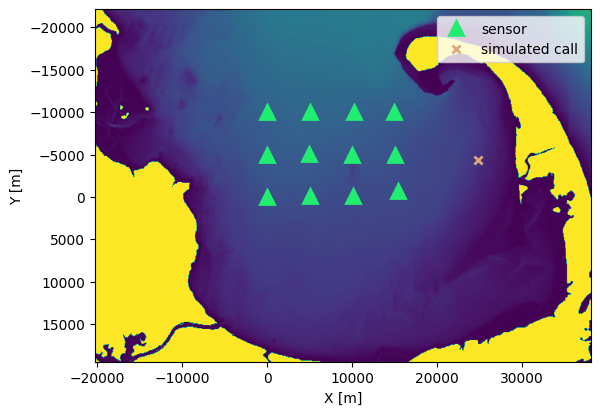

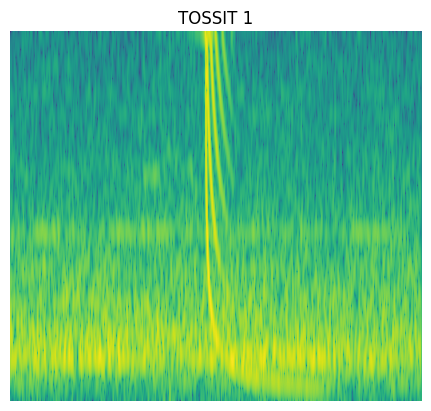

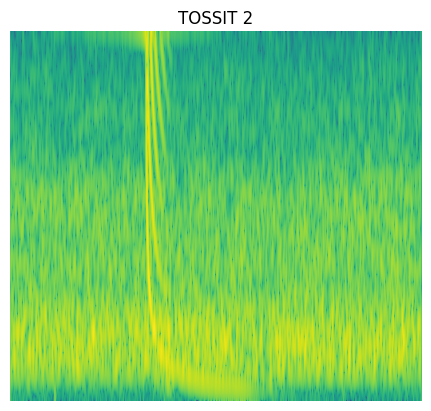

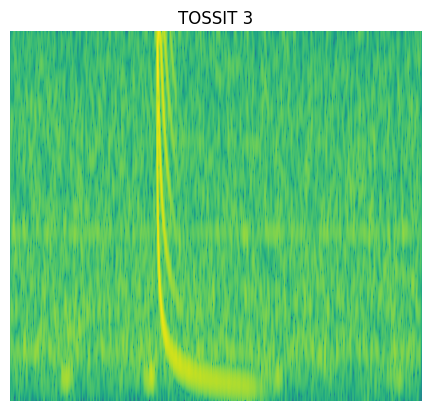

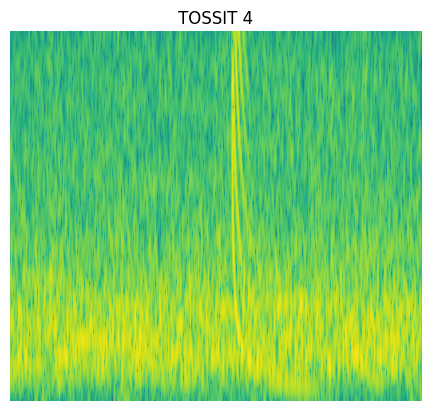

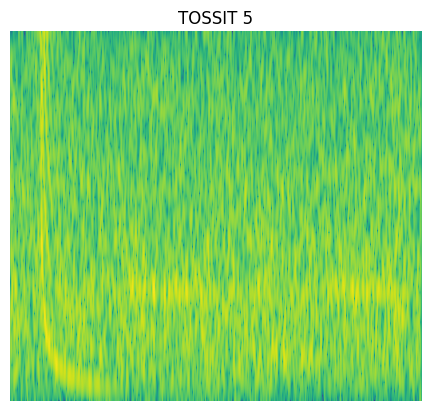

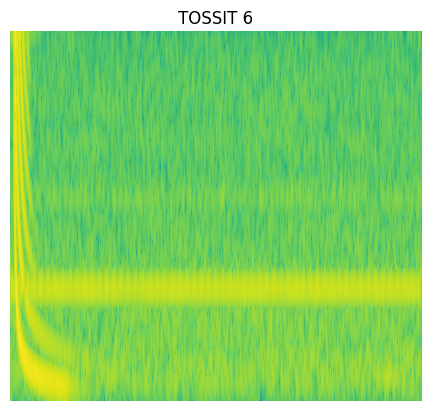

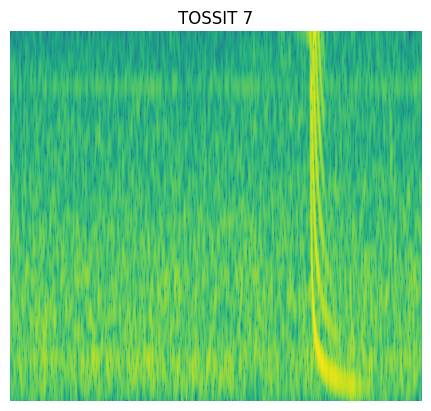

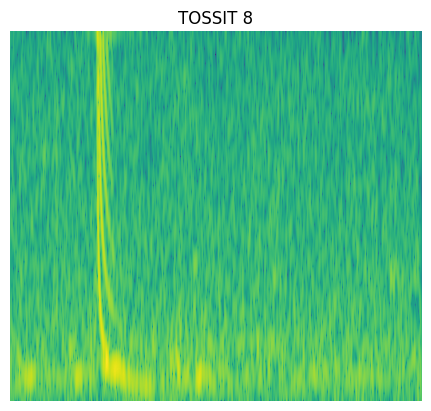

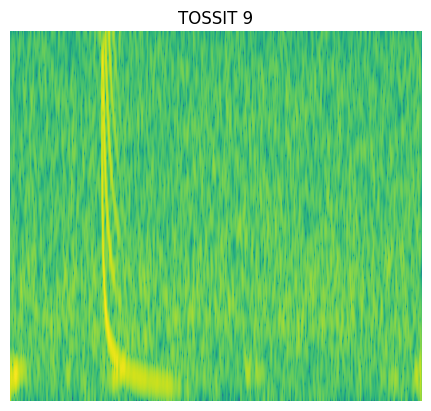

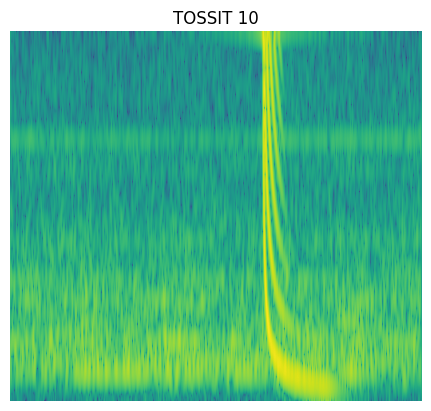

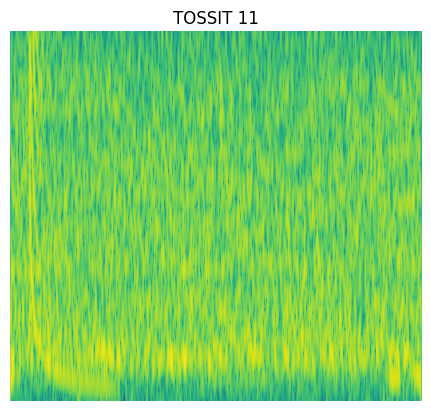

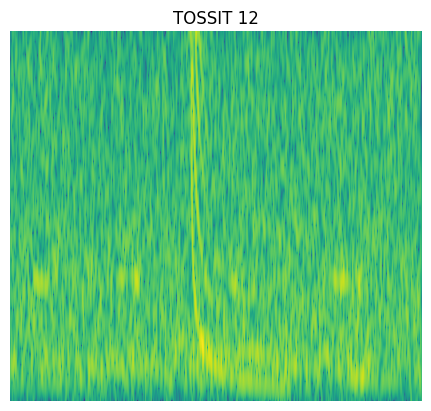

In [3]:
# call selection
call = 169980

with h5py.File(config['dataset']['data_directory'] + "/VDS_main.h5", 'r') as f:
    signals = f['data'][call,:,:]
    num_TOSSITs = f['data'].shape[1]
#     y_loc = f['labels'][call,0]
#     x_loc = f['labels'][call,1]
#     cb = f['labels'][call,2]
#     cw = f['labels'][call,3]
#     zs = f['labels'][call,4]
#     c = f['class_labels'][call].squeeze()
#     snrs = f['labels'][call,6:]
#     valid = f['labels'][call,5]
#     ranges = f['range_labels'][call,:]

    y_loc = f['labels'][call,0]
    x_loc = f['labels'][call,1]
    cw = f['labels'][call,2:5]
    cw_z = f['labels'][call,5]
    c_sed = f['labels'][call,6]
    sed_D = f['labels'][call,7]
    cb = f['labels'][call,8]
    zs = f['labels'][call,9]
    valid = f['labels'][call,10]
    ranges = f['range_labels'][call,:].flatten()
    snrs = f['labels'][call,11:]
    c = f['class_labels'][call].squeeze()

plot_localization(np.asarray([[y_loc, x_loc]]), buffer=2000, bathym=bathym)    

for t in range(num_TOSSITs):
    spect = to_spect(signals[t])
    plt.figure()
    plt.imshow(spect.squeeze())
    plt.title(f"TOSSIT {t+1}")
    plt.axis('off')

print("Labels")
print("-------------------")
print("Y:\t" + str(np.around(y_loc,2)) + " m")
print("X:\t" + str(np.around(x_loc,2)) + " m")
print("cw:\t" + str(cw) + " m/s")
print("cw_z:\t" + str(cw_z))
print("c_sed:\t" + str(c_sed) + " m/s")
print("sed_D:\t" + str(sed_D) + " m")
print("cb:\t" + str(cb) + " m/s")
print("zs:\t" + str(zs) + " m")
print("class:\t" + str(c))
print("valid:\t" + str(valid))
print("SNRs:\t" + str(np.around(snrs,2)))
print("ranges:\t" + str(np.around(ranges,2)))

### Visualize Synthetic Data Labels Distributions

35028.582


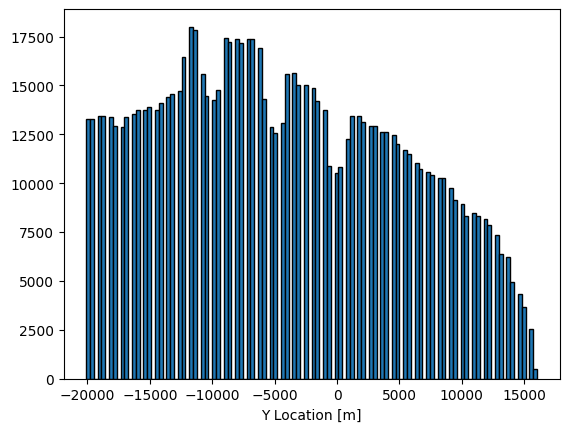

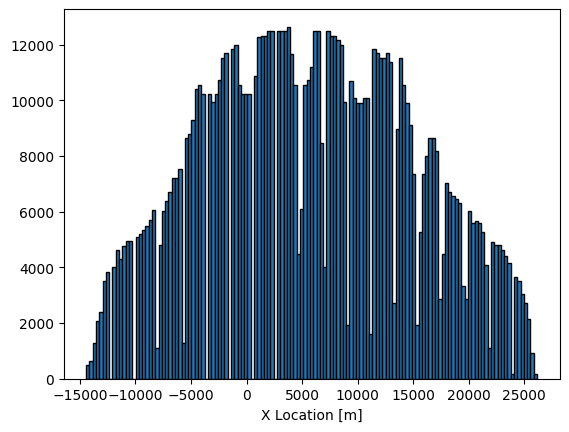

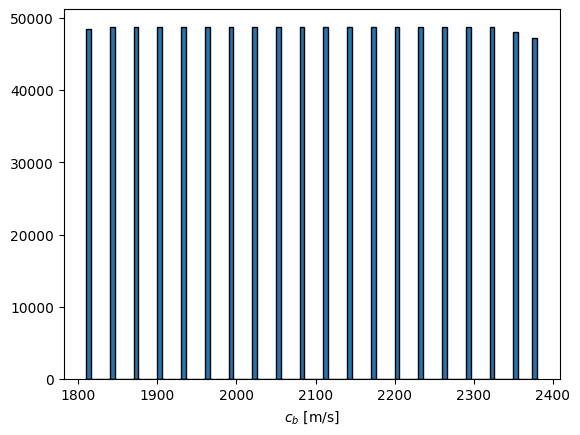

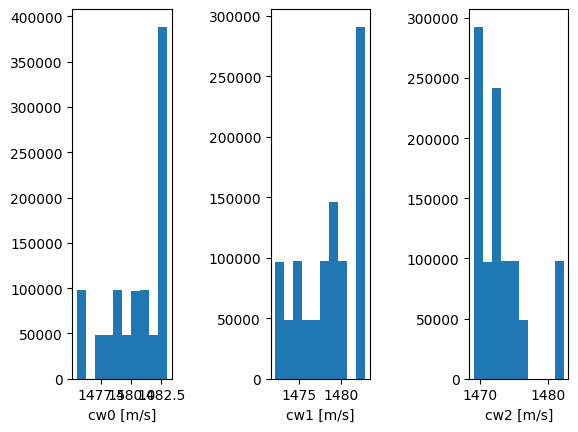

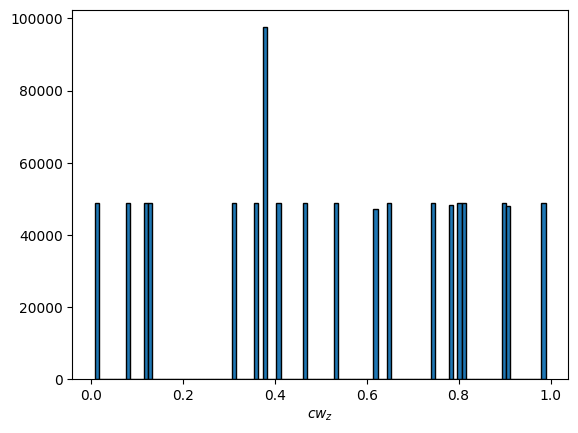

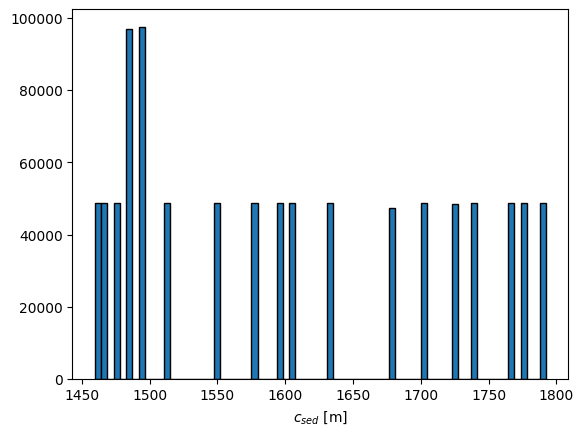

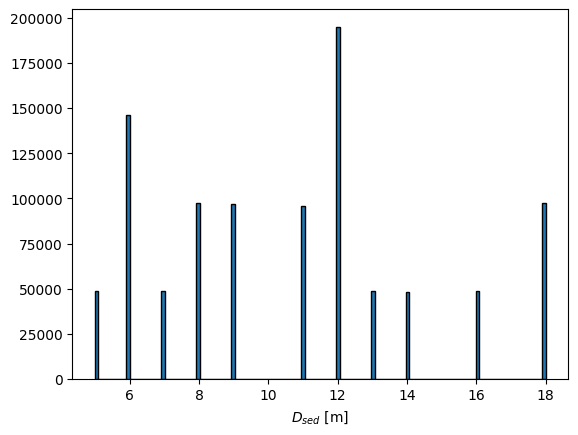

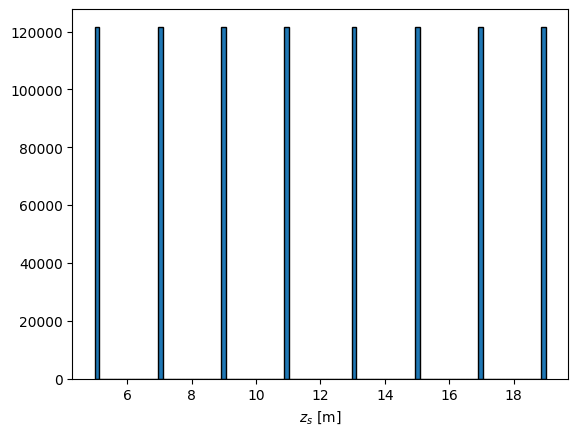

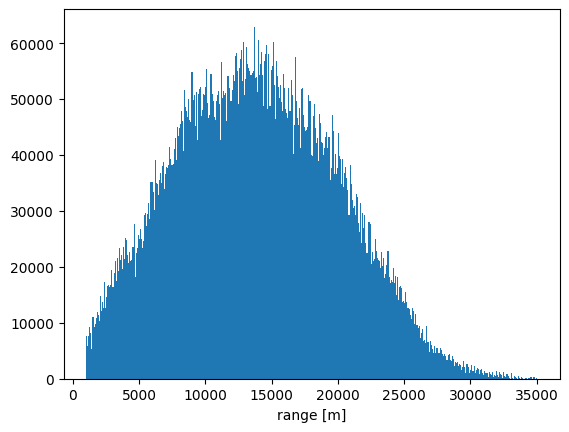

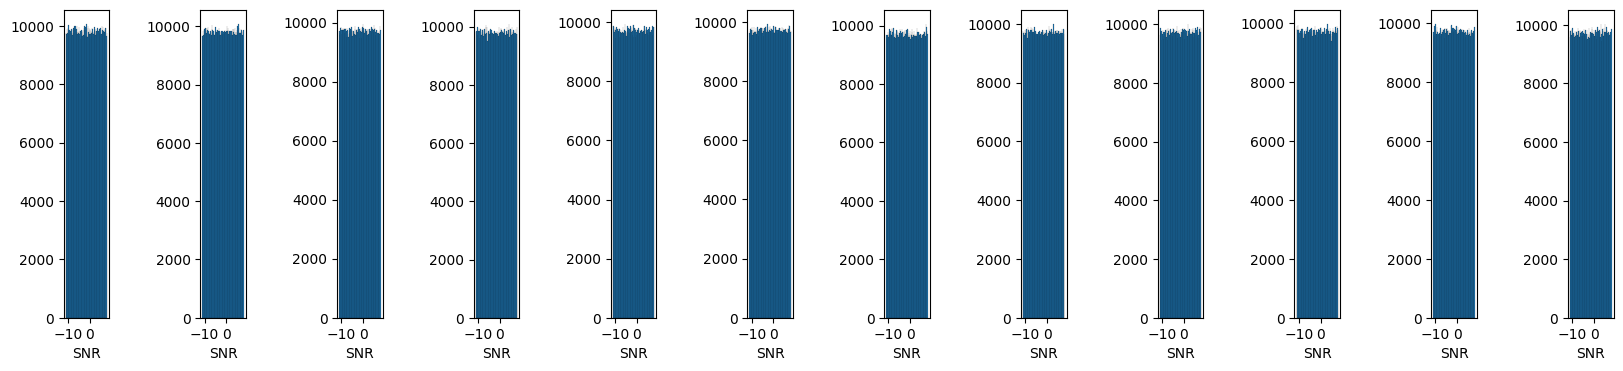

In [6]:
with h5py.File(config['dataset']['data_directory'] + "/VDS_main.h5", 'r') as f:
    num_TOSSITs = f['data'].shape[1]
#     y_loc = f['labels'][:,0]
#     x_loc = f['labels'][:,1]
#     cb = f['labels'][:,2]
#     cw = f['labels'][:,3]
#     zs = f['labels'][:,4]
#     snrs = f['labels'][:,6:]
#     ranges = f['range_labels'][:].flatten()
    y_loc = f['labels'][:,0]
    x_loc = f['labels'][:,1]
    cw = f['labels'][:,2:5]
    cw_z = f['labels'][:,5]
    c_sed = f['labels'][:,6]
    sed_D = f['labels'][:,7]
    cb = f['labels'][:,8]
    zs = f['labels'][:,9]
    valid = f['labels'][:,10]
    ranges = f['range_labels'][:].flatten()
    snrs = f['labels'][:,11:]
    c = f['class_labels'][:].squeeze()
    print(np.max(ranges))
# plt.figure()
# plt.hist(y_loc, bins='auto', edgecolor='black')
# plt.xlabel("Y Location [m]")

# plt.figure()
# plt.hist(x_loc, bins='auto', edgecolor='black')
# plt.xlabel("X Location [m]")

# plt.figure()
# plt.hist(cb, bins='auto', edgecolor='black')
# plt.xlabel("$c_{b}$ [m/s]")

# plt.figure()
# plt.hist(cw, bins='auto', edgecolor='black')
# plt.xlabel("$c_{w}$ [m/s]")

# plt.figure()
# plt.hist(zs, bins='auto', edgecolor='black')
# plt.xlabel("$z_{s}$ [m]")

# plt.figure()
# plt.hist(ranges, bins='auto')
# plt.xlabel("range [m]")

# plt.figure()
# for i in range(num_TOSSITs):
#     plt.subplot(1,num_TOSSITs,i+1)
#     plt.hist(snrs[:,i], bins='auto', edgecolor='black', linewidth=0.1)
#     plt.xlabel("SNR")
#     plt.title(f"TOSSIT {i+1}")

plt.figure()
plt.hist(y_loc, bins='auto', edgecolor='black')
plt.xlabel("Y Location [m]")

plt.figure()
plt.hist(x_loc, bins='auto', edgecolor='black')
plt.xlabel("X Location [m]")

plt.figure()
plt.hist(cb, bins='auto', edgecolor='black')
plt.xlabel("$c_{b}$ [m/s]")

fig, axs = plt.subplots(1,3)
for i in range(cw.shape[1]):
    axs[i].hist(cw[:,i])
    axs[i].set_xlabel(f"cw{i} [m/s]")
fig.subplots_adjust(wspace=1)

plt.figure()
plt.hist(cw_z, bins='auto', edgecolor='black')
plt.xlabel("$cw_{z}$")

plt.figure()
plt.hist(c_sed, bins='auto', edgecolor='black')
plt.xlabel("$c_{sed}$ [m]")

plt.figure()
plt.hist(sed_D, bins='auto', edgecolor='black')
plt.xlabel("$D_{sed}$ [m]")

plt.figure()
plt.hist(zs, bins='auto', edgecolor='black')
plt.xlabel("$z_{s}$ [m]")

plt.figure()
plt.hist(ranges, bins='auto')
plt.xlabel("range [m]")

fig, axs = plt.subplots(1,num_TOSSITs, figsize=(20,4))
for i in range(num_TOSSITs):
    axs[i].hist(snrs[:,i], bins='auto', edgecolor='black', linewidth=0.1)
    axs[i].set_xlabel("SNR")
fig.subplots_adjust(wspace=2)

Text(0.5, 1.0, 'Synthetic Sound Speed Profiles')

<Figure size 640x480 with 0 Axes>

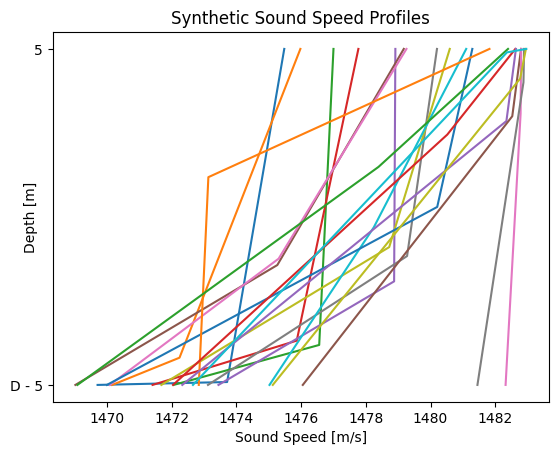

In [8]:
unique_SSPs = np.fliplr(np.unique(cw, axis=0))
unique_z_fracs = np.unique(cw_z)

fig = plt.figure()
ax = plt.figure().gca()
ax.xaxis.get_major_locator().set_params(integer=True)
ax.set_yticks([0, 2])
ax.set_yticklabels(["D - 5", "5"])
for i in range(unique_SSPs.shape[0]):
    plt.plot(unique_SSPs[i,:], [0, 2*unique_z_fracs[i], 2])
ax.set_xlabel("Sound Speed [m/s]")
ax.set_ylabel("Depth [m]", labelpad=-20)
ax.set_title("Synthetic Sound Speed Profiles")

### Visualize Experimental Data

Labels
-------------------
Y:	nan m
X:	nan m


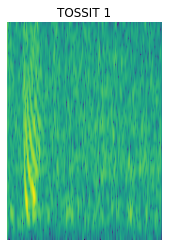

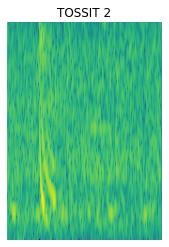

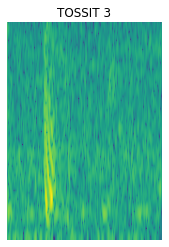

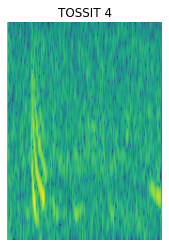

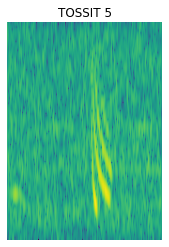

In [30]:
# call selection if more than one
call = 1

with h5py.File(config['dataset']['exp_data_directory'] + "/" + config['dataset']['exp_data_file'], 'r') as f:
    if len(f['data'].shape) == 2:
        num_TOSSITs = f['data'].shape[0]
        signals = f['data'][:]
        y_loc = f['labels'][:,0].squeeze()
        x_loc = f['labels'][:,1].squeeze()
    else:
        num_TOSSITs = f['data'].shape[1]
        signals = f['data'][call,:,:]
        y_loc = f['labels'][call,0].squeeze()
        x_loc = f['labels'][call,1].squeeze()
        
print("Labels")
print("-------------------")
print("Y:\t" + str(np.around(y_loc,2)) + " m")
print("X:\t" + str(np.around(x_loc,2)) + " m")

for t in range(num_TOSSITs):
    spect = to_spect(signals[t])
    plt.figure()
    plt.imshow(spect.squeeze())
    plt.title(f"TOSSIT {t+1}")
    plt.axis('off')